# 08 — Modeling

Goal: find the best classifier for the news source classification task and understand what it's learning.

Sections:
1. Data loading and train/test split
2. Baseline — TF-IDF logistic regression (reproduce assignment baseline)
3. MiniLM embeddings — logistic regression, SVM, random forest
4. Model comparison and selection
5. Error analysis — what is the best model getting wrong?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

plt.rcParams['figure.dpi'] = 120
FOX_COLOR = '#E81B23'
NBC_COLOR = '#2A5EAC'

/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Data Loading and Train/Test Split

In [3]:
df = pd.read_csv('../data/processed/combined_base_data.csv')
df['datetime_posted'] = pd.to_datetime(df['datetime_posted'], utc=True, format = "mixed")
df = df.dropna(subset=['title']).copy()

print(f'Total articles: {len(df):,}')
print(f'Missing datetimes: {df["datetime_posted"].isna().sum()}')
print(f'Fox: {df["is_fox"].sum():,} | NBC: {(df["is_fox"]==0).sum():,}')

Total articles: 3,801
Missing datetimes: 90
Fox: 2,000 | NBC: 1,801


In [4]:
# Time-based split on rows with valid datetimes
# Rows missing datetimes go into training only — we don't want them in the test set
# since we can't verify their temporal position
df_dated = df.dropna(subset=['datetime_posted']).sort_values('datetime_posted')
df_undated = df[df['datetime_posted'].isna()]

split_idx = int(len(df_dated) * 0.8)
train_dated = df_dated.iloc[:split_idx]
test = df_dated.iloc[split_idx:]

# Combine dated train rows with undated rows for training
train = pd.concat([train_dated, df_undated], ignore_index=True)

print(f'Train: {len(train):,} | Fox%: {train["is_fox"].mean():.2%}')
print(f'Test:  {len(test):,}  | Fox%: {test["is_fox"].mean():.2%}')
print(f'Test date range: {test["datetime_posted"].min().date()} -> {test["datetime_posted"].max().date()}')

Train: 3,058 | Fox%: 52.22%
Test:  743  | Fox%: 54.24%
Test date range: 2024-09-27 -> 2026-04-07


In [5]:
# Check class balance is reasonable — if test is severely skewed revert to stratified split
train_fox_pct = train['is_fox'].mean()
test_fox_pct = test['is_fox'].mean()

if abs(train_fox_pct - test_fox_pct) > 0.2:
    print(f'WARNING: large class imbalance between train ({train_fox_pct:.2%} Fox) '
          f'and test ({test_fox_pct:.2%} Fox)')
    print('Falling back to stratified random split')
    train, test = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df['is_fox']
    )
    print(f'Train: {len(train):,} | Fox%: {train["is_fox"].mean():.2%}')
    print(f'Test:  {len(test):,}  | Fox%: {test["is_fox"].mean():.2%}')
else:
    print('Class balance looks good, keeping time-based split')

X_train_text = train['title'].tolist()
X_test_text = test['title'].tolist()
y_train = train['is_fox'].tolist()
y_test = test['is_fox'].tolist()

Class balance looks good, keeping time-based split


## 2 — Baseline: TF-IDF Logistic Regression

Reproducing the assignment baseline (66.49%) on our data as a local benchmark. We use the same settings as the assignment code: 100 TF-IDF features, logistic regression.

In [6]:
# Exact assignment baseline settings
vectorizer_baseline = TfidfVectorizer(stop_words='english', max_features=100)
X_train_baseline = vectorizer_baseline.fit_transform(X_train_text)
X_test_baseline = vectorizer_baseline.transform(X_test_text)

lr_baseline = LogisticRegression(max_iter=100, random_state=42)
lr_baseline.fit(X_train_baseline, y_train)
y_pred_baseline = lr_baseline.predict(X_test_baseline)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f'Baseline accuracy: {acc_baseline:.4f}')
print(classification_report(y_test, y_pred_baseline, target_names=['NBC', 'Fox']))

Baseline accuracy: 0.6864
              precision    recall  f1-score   support

         NBC       0.69      0.56      0.62       340
         Fox       0.68      0.79      0.73       403

    accuracy                           0.69       743
   macro avg       0.69      0.68      0.68       743
weighted avg       0.69      0.69      0.68       743



In [7]:
# Improved TF-IDF — more features, bigrams, tuned regularization
vectorizer_improved = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2),  # unigrams and bigrams
    sublinear_tf=True,   # dampen effect of very frequent terms
)
X_train_tfidf = vectorizer_improved.fit_transform(X_train_text)
X_test_tfidf = vectorizer_improved.transform(X_test_text)

lr_tfidf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f'Improved TF-IDF LR accuracy: {acc_tfidf:.4f}')
print(classification_report(y_test, y_pred_tfidf, target_names=['NBC', 'Fox']))

Improved TF-IDF LR accuracy: 0.7362
              precision    recall  f1-score   support

         NBC       0.72      0.69      0.70       340
         Fox       0.75      0.78      0.76       403

    accuracy                           0.74       743
   macro avg       0.73      0.73      0.73       743
weighted avg       0.74      0.74      0.74       743



## 3 — MiniLM Embeddings

Encode headlines with `all-MiniLM-L6-v2` and try multiple classifiers on top.
Embeddings are pre-computed once and reused across all classifiers.

In [8]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding train set...')
X_train_emb = embedder.encode(X_train_text, show_progress_bar=True)
print('Encoding test set...')
X_test_emb = embedder.encode(X_test_text, show_progress_bar=True)

print(f'Embedding shape: {X_train_emb.shape}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8470.52it/s]


Encoding train set...


Batches: 100%|██████████| 96/96 [00:03<00:00, 29.72it/s]


Encoding test set...


Batches: 100%|██████████| 24/24 [00:00<00:00, 41.17it/s]

Embedding shape: (3058, 384)


In [9]:
# Scale embeddings — logistic regression and SVM both benefit from this
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)

In [10]:
# Logistic regression on embeddings
lr_emb = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_emb.fit(X_train_scaled, y_train)
y_pred_lr_emb = lr_emb.predict(X_test_scaled)

acc_lr_emb = accuracy_score(y_test, y_pred_lr_emb)
print(f'MiniLM + Logistic Regression accuracy: {acc_lr_emb:.4f}')
print(classification_report(y_test, y_pred_lr_emb, target_names=['NBC', 'Fox']))

MiniLM + Logistic Regression accuracy: 0.7120
              precision    recall  f1-score   support

         NBC       0.69      0.68      0.68       340
         Fox       0.73      0.74      0.74       403

    accuracy                           0.71       743
   macro avg       0.71      0.71      0.71       743
weighted avg       0.71      0.71      0.71       743



In [11]:
# SVM with RBF kernel
svm = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'MiniLM + SVM (RBF) accuracy: {acc_svm:.4f}')
print(classification_report(y_test, y_pred_svm, target_names=['NBC', 'Fox']))

MiniLM + SVM (RBF) accuracy: 0.7550
              precision    recall  f1-score   support

         NBC       0.74      0.72      0.73       340
         Fox       0.77      0.79      0.78       403

    accuracy                           0.76       743
   macro avg       0.75      0.75      0.75       743
weighted avg       0.75      0.76      0.75       743



In [12]:
# Random forest — no scaling needed, included for comparison
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_emb, y_train)
y_pred_rf = rf.predict(X_test_emb)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'MiniLM + Random Forest accuracy: {acc_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['NBC', 'Fox']))

MiniLM + Random Forest accuracy: 0.7120
              precision    recall  f1-score   support

         NBC       0.73      0.59      0.65       340
         Fox       0.70      0.81      0.75       403

    accuracy                           0.71       743
   macro avg       0.71      0.70      0.70       743
weighted avg       0.71      0.71      0.71       743



## 4 — Model Comparison

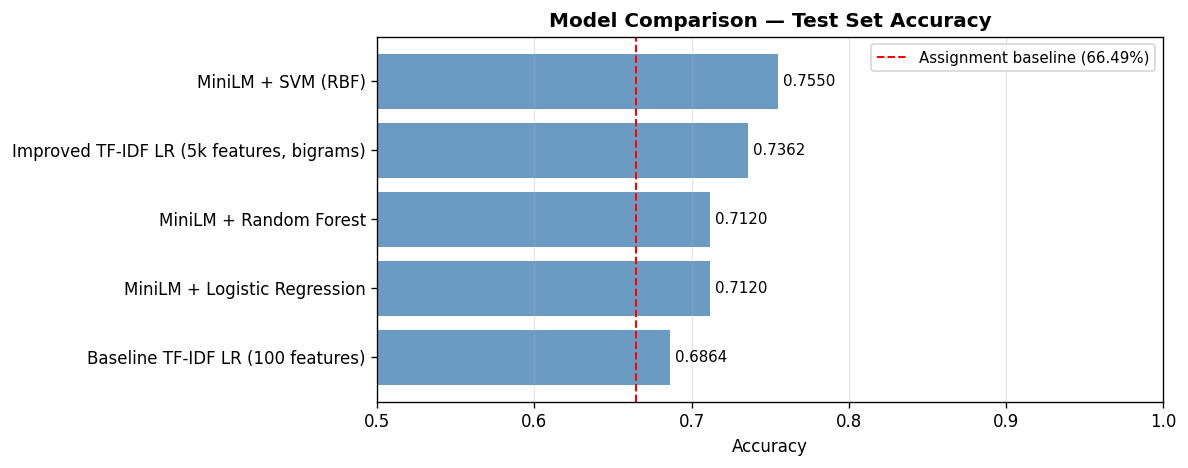


Best model: MiniLM + SVM (RBF) (0.7550)


In [14]:
results = {
    'Baseline TF-IDF LR (100 features)': acc_baseline,
    'Improved TF-IDF LR (5k features, bigrams)': acc_tfidf,
    'MiniLM + Logistic Regression': acc_lr_emb,
    'MiniLM + SVM (RBF)': acc_svm,
    'MiniLM + Random Forest': acc_rf,
}

results_df = pd.Series(results).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(results_df.index, results_df.values, color='steelblue', alpha=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.axvline(0.6649, color='red', linestyle='--', linewidth=1.2, label='Assignment baseline (66.49%)')
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison — Test Set Accuracy', fontweight='bold')
ax.set_xlim(0.5, 1.0)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

best_model_name = results_df.idxmax()
print(f'\nBest model: {best_model_name} ({results_df.max():.4f})')

## 5 — Error Analysis

What is the best model getting wrong? Spot-checking errors often reveals something interesting — are the misclassified headlines genuinely ambiguous, or is there a systematic pattern?

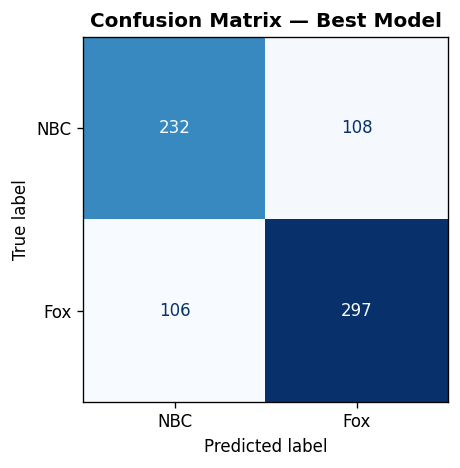

In [16]:
# Use best embedding model for error analysis
# Update y_pred_best to whichever model won above
best_preds = y_pred_lr_emb  # update this if SVM or RF won

test_df = test.copy().reset_index(drop=True)
test_df['predicted'] = best_preds
test_df['correct'] = test_df['predicted'] == test_df['is_fox']

# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NBC', 'Fox'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Best Model', fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Fox headlines misclassified as NBC
fox_as_nbc = test_df[(test_df['is_fox'] == 1) & (test_df['predicted'] == 0)]
print(f'Fox misclassified as NBC: {len(fox_as_nbc)}')
print()
for t in fox_as_nbc['title'].sample(min(8, len(fox_as_nbc)), random_state=42):
    print(' ', t)

Fox misclassified as NBC: 106

  Sinwar's ruthless brother Mohammed slated to take over as leader of Hamas
  Israel's ground invasion into Lebanon imminent as cabinet approves next phase of the war
  Panthers owners donates $3 million to Hurricane Helene relief efforts; Bucs also give seven figures
  Who was Yahya Sinwar? The Israeli prisoner turned terrorist Hamas leader killed by IDF troops
  Would-be Trump assassin wants Judge Cannon to recuse herself for dismissing document case
  Trump and Harris poll in dead heat in NBC News survey as Election Day approaches
  American father of Hamas hostage Itay Chen pushes US, Israel on ‘Plan B’ as negotiations falter
  Hamas launches rockets from Gaza one year after Oct. 7 attacks, while IDF strikes terror targets


In [18]:
# NBC headlines misclassified as Fox
nbc_as_fox = test_df[(test_df['is_fox'] == 0) & (test_df['predicted'] == 1)]
print(f'NBC misclassified as Fox: {len(nbc_as_fox)}')
print()
for t in nbc_as_fox['title'].sample(min(8, len(nbc_as_fox)), random_state=42):
    print(' ', t)

NBC misclassified as Fox: 108

  S.C. man sentenced to life in prison for murdering Black trans woman after historic verdict
  Melania Trump says Donald Trump 'knew my position and my beliefs' on abortion 'since the day we met'
  Arizona abortion-rights advocates pour $15 million into ballot measure ad blitz
  Elon Musk announces $1M giveaway for voters who sign petition in battleground states
  A Black conservative radio host invoked 'field' and 'house' slaves in arguing why some Black men back Trump
  Being Gronk: How this actor and stunt double plays the NFL legend on screen
  Kamala Harris sees path to victory in Pennsylvania running through the suburbs
  GOP donors pour hundreds of millions into pro-Trump super PACs before Election Day


In [19]:
# Are errors concentrated in certain categories or topics?
if 'category' in test_df.columns:
    error_by_cat = test_df.groupby('category').agg(
        n=('title', 'count'),
        error_rate=('correct', lambda x: 1 - x.mean())
    ).sort_values('error_rate', ascending=False)
    print('Error rate by category (min 5 articles):')
    print(error_by_cat[error_by_cat['n'] >= 5].round(3).to_string())

Error rate by category (min 5 articles):
                 n  error_rate
category                      
us-news         13       0.769
nbc-out          6       0.667
tech            15       0.467
travel          14       0.429
opinion         10       0.400
politics       231       0.377
world           58       0.362
us              42       0.357
other            6       0.333
sports          49       0.286
health          13       0.231
asian-america    5       0.200
select         124       0.185
lifestyle       12       0.167
entertainment   23       0.130
food-drink      10       0.100
media           80       0.075
science          8       0.000
weather          5       0.000


In [20]:
# # Save embeddings and scaler for reuse in later notebooks (PCA, SHAP)
# import os
# os.makedirs('data/interim', exist_ok=True)
# np.save('data/interim/X_train_emb.npy', X_train_emb)
# np.save('data/interim/X_test_emb.npy', X_test_emb)
# np.save('data/interim/y_train.npy', np.array(y_train))
# np.save('data/interim/y_test.npy', np.array(y_test))
# print('Saved embeddings and labels to data/interim/')

# # Save train/test text for SHAP notebook
# train.to_csv('data/interim/train.csv', index=False)
# test.to_csv('data/interim/test.csv', index=False)
# print('Saved train/test CSVs to data/interim/')

## 6 — Style Features Augmentation

From EDA we know Fox/NBC differences are largely stylistic — single quotes, colons, headline length. MiniLM encodes *meaning*, so it misses these signals. Here we concatenate explicit style features onto the embeddings and rerun all three classifiers.

If style features help, it confirms the EDA finding: the signal the classifier needs is partly stylistic, not just semantic.

In [21]:
def compute_style_features(df):
    """Compute the same style features used in the EDA notebook."""
    out = pd.DataFrame(index=df.index)
    titles = df['title'].fillna('')
    out['word_count'] = titles.str.split().str.len()
    out['char_count'] = titles.str.len()
    out['has_single_quotes'] = titles.str.contains(r"'[^']{1,40}'", regex=True).astype(float)
    out['has_question'] = titles.str.endswith('?').astype(float)
    out['has_colon'] = titles.str.contains(':', regex=False).astype(float)
    out['has_allcaps'] = titles.str.contains(r'\b[A-Z]{3,}\b', regex=True).astype(float)
    return out.values.astype(float)

train_style = compute_style_features(train)
test_style = compute_style_features(test)

# Scale style features separately then concatenate with scaled embeddings
style_scaler = StandardScaler()
train_style_scaled = style_scaler.fit_transform(train_style)
test_style_scaled = style_scaler.transform(test_style)

X_train_combined = np.hstack([X_train_scaled, train_style_scaled])
X_test_combined = np.hstack([X_test_scaled, test_style_scaled])

print(f'Combined feature shape: {X_train_combined.shape}')

Combined feature shape: (3058, 390)


In [22]:
# LR on combined features
lr_combined = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_combined.fit(X_train_combined, y_train)
acc_lr_combined = accuracy_score(y_test, lr_combined.predict(X_test_combined))
print(f'MiniLM + style + LR: {acc_lr_combined:.4f}')

# SVM on combined features
svm_combined = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
svm_combined.fit(X_train_combined, y_train)
y_pred_svm_combined = svm_combined.predict(X_test_combined)
acc_svm_combined = accuracy_score(y_test, y_pred_svm_combined)
print(f'MiniLM + style + SVM: {acc_svm_combined:.4f}')

# RF on combined features (unscaled embeddings + scaled style)
X_train_combined_rf = np.hstack([X_train_emb, train_style_scaled])
X_test_combined_rf = np.hstack([X_test_emb, test_style_scaled])
rf_combined = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined_rf, y_train)
acc_rf_combined = accuracy_score(y_test, rf_combined.predict(X_test_combined_rf))
print(f'MiniLM + style + RF:  {acc_rf_combined:.4f}')

MiniLM + style + LR: 0.7443
MiniLM + style + SVM: 0.7739
MiniLM + style + RF:  0.7402


## 7 — Stratified Split Comparison

Rerun the best configurations on a stratified random split to quantify how much distribution shift costs us. The gap between time-based and stratified accuracy is itself a finding — it tells us how much the model degrades on more recent articles.

In [23]:
train_s, test_s = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_fox'])

print(f'Stratified train: {len(train_s):,} | Fox%: {train_s["is_fox"].mean():.2%}')
print(f'Stratified test:  {len(test_s):,}  | Fox%: {test_s["is_fox"].mean():.2%}')

X_train_s_text = train_s['title'].tolist()
X_test_s_text = test_s['title'].tolist()
y_train_s = train_s['is_fox'].tolist()
y_test_s = test_s['is_fox'].tolist()

Stratified train: 3,040 | Fox%: 52.63%
Stratified test:  761  | Fox%: 52.56%


In [24]:
# Encode with MiniLM
print('Encoding stratified splits...')
X_train_s_emb = embedder.encode(X_train_s_text, show_progress_bar=True)
X_test_s_emb = embedder.encode(X_test_s_text, show_progress_bar=True)

scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s_emb)
X_test_s_scaled = scaler_s.transform(X_test_s_emb)

# Style features
train_s_style = compute_style_features(train_s)
test_s_style = compute_style_features(test_s)
style_scaler_s = StandardScaler()
train_s_style_scaled = style_scaler_s.fit_transform(train_s_style)
test_s_style_scaled = style_scaler_s.transform(test_s_style)

X_train_s_combined = np.hstack([X_train_s_scaled, train_s_style_scaled])
X_test_s_combined = np.hstack([X_test_s_scaled, test_s_style_scaled])

Encoding stratified splits...


Batches: 100%|██████████| 24/24 [00:00<00:00, 32.24it/s]


In [25]:
# Baseline on stratified
vec_s = TfidfVectorizer(stop_words='english', max_features=100)
lr_base_s = LogisticRegression(max_iter=100, random_state=42)
lr_base_s.fit(vec_s.fit_transform(X_train_s_text), y_train_s)
acc_baseline_s = accuracy_score(y_test_s, lr_base_s.predict(vec_s.transform(X_test_s_text)))
print(f'Baseline TF-IDF LR (stratified):      {acc_baseline_s:.4f}')

# SVM embeddings only on stratified
svm_s = SVC(kernel='rbf', C=1.0, random_state=42)
svm_s.fit(X_train_s_scaled, y_train_s)
acc_svm_s = accuracy_score(y_test_s, svm_s.predict(X_test_s_scaled))
print(f'MiniLM + SVM (stratified):            {acc_svm_s:.4f}')

# SVM + style on stratified
svm_combined_s = SVC(kernel='rbf', C=1.0, random_state=42)
svm_combined_s.fit(X_train_s_combined, y_train_s)
acc_svm_combined_s = accuracy_score(y_test_s, svm_combined_s.predict(X_test_s_combined))
print(f'MiniLM + style + SVM (stratified):    {acc_svm_combined_s:.4f}')

Baseline TF-IDF LR (stratified):      0.7096
MiniLM + SVM (stratified):            0.8055
MiniLM + style + SVM (stratified):    0.8265


## 8 — TF-IDF Feature Count Ablation

How much does the number of TF-IDF features matter? This gives a learning curve that's useful for the report and shows the point of diminishing returns.

TF-IDF features=   100: 0.6824
TF-IDF features=   500: 0.7066
TF-IDF features=  1000: 0.7133
TF-IDF features=  2000: 0.7174
TF-IDF features=  5000: 0.7362
TF-IDF features= 10000: 0.7416


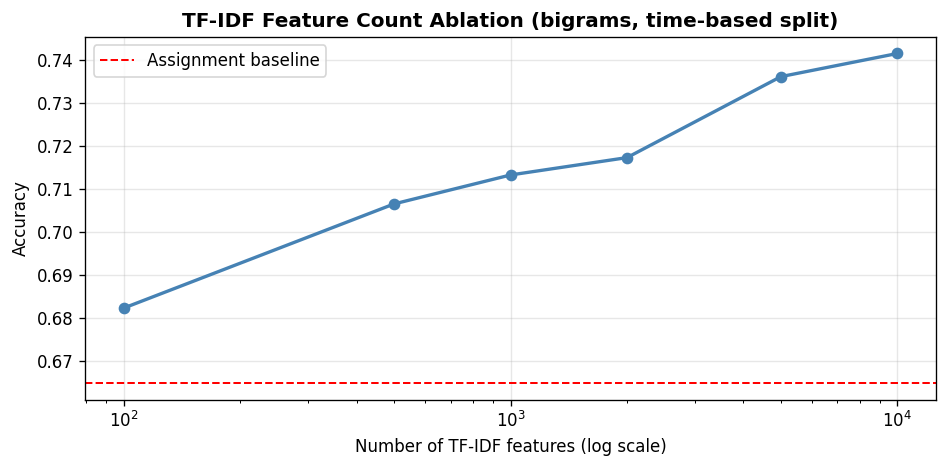

In [27]:
feature_counts = [100, 500, 1000, 2000, 5000, 10000]
tfidf_ablation = {}

for n in feature_counts:
    vec = TfidfVectorizer(
        stop_words='english',
        max_features=n,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )
    lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    lr.fit(vec.fit_transform(X_train_text), y_train)
    acc = accuracy_score(y_test, lr.predict(vec.transform(X_test_text)))
    tfidf_ablation[n] = acc
    print(f'TF-IDF features={n:>6}: {acc:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(tfidf_ablation.keys()), list(tfidf_ablation.values()),
        marker='o', linewidth=2, color='steelblue')
ax.axhline(0.6649, color='red', linestyle='--', linewidth=1.2, label='Assignment baseline')
ax.set_xscale('log')
ax.set_xlabel('Number of TF-IDF features (log scale)')
ax.set_ylabel('Accuracy')
ax.set_title('TF-IDF Feature Count Ablation (bigrams, time-based split)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9 — Full Comparison Chart

All configurations across both split types in one view.

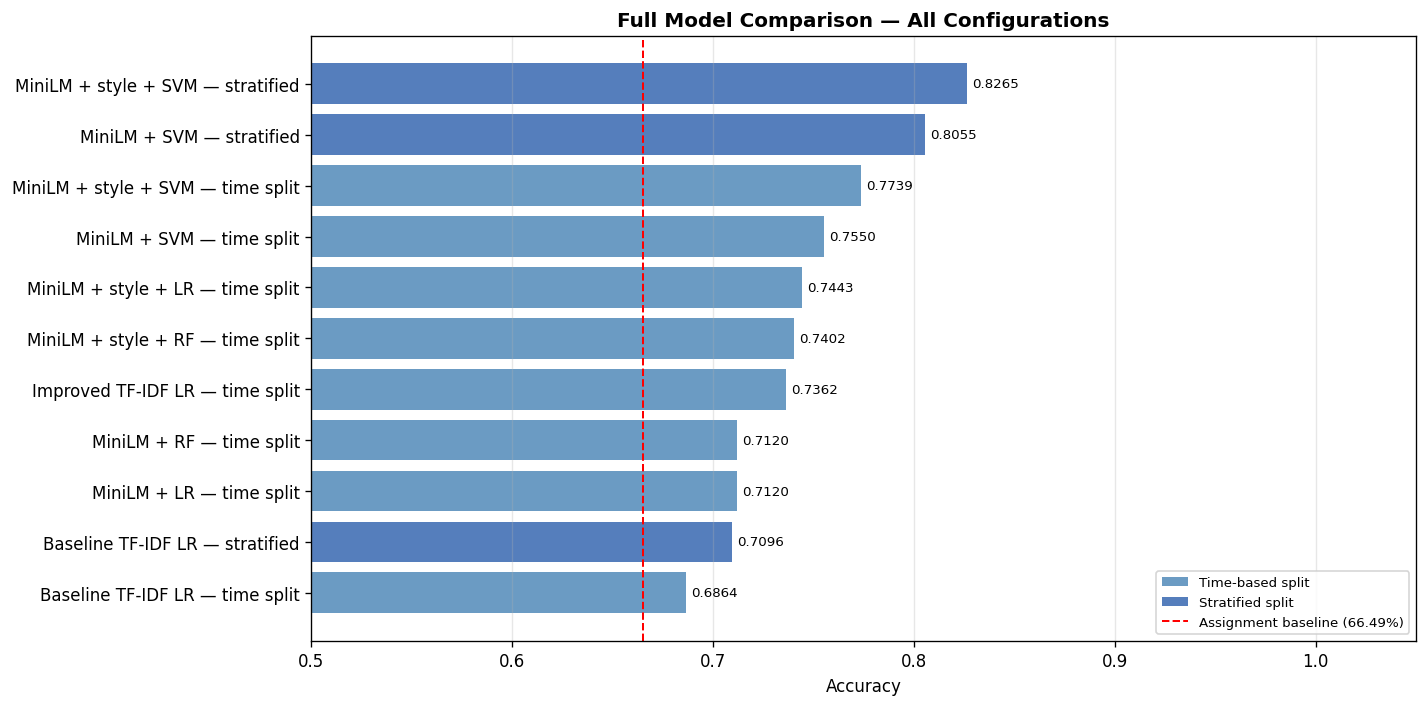


Best overall: MiniLM + style + SVM — stratified (0.8265)
Best time-based: MiniLM + style + SVM — time split
Best stratified: MiniLM + style + SVM — stratified


In [28]:
all_results = {
    # Time-based split
    'Baseline TF-IDF LR — time split': acc_baseline,
    'Improved TF-IDF LR — time split': acc_tfidf,
    'MiniLM + LR — time split': acc_lr_emb,
    'MiniLM + RF — time split': acc_rf,
    'MiniLM + SVM — time split': acc_svm,
    'MiniLM + style + LR — time split': acc_lr_combined,
    'MiniLM + style + RF — time split': acc_rf_combined,
    'MiniLM + style + SVM — time split': acc_svm_combined,
    # Stratified split
    'Baseline TF-IDF LR — stratified': acc_baseline_s,
    'MiniLM + SVM — stratified': acc_svm_s,
    'MiniLM + style + SVM — stratified': acc_svm_combined_s,
}

results_df = pd.Series(all_results).sort_values(ascending=True)

# Color bars by split type
colors = ['#2A5EAC' if 'stratified' in k else 'steelblue' for k in results_df.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(results_df.index, results_df.values, color=colors, alpha=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.axvline(0.6649, color='red', linestyle='--', linewidth=1.2, label='Assignment baseline (66.49%)')
ax.set_xlabel('Accuracy')
ax.set_title('Full Model Comparison — All Configurations', fontweight='bold')
ax.set_xlim(0.5, 1.05)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Legend for split type colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.8, label='Time-based split'),
    Patch(facecolor='#2A5EAC', alpha=0.8, label='Stratified split'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0],
          fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

print(f'\nBest overall: {results_df.idxmax()} ({results_df.max():.4f})')
print(f'Best time-based: {pd.Series({k: v for k, v in all_results.items() if "time" in k}).idxmax()}')
print(f'Best stratified: {pd.Series({k: v for k, v in all_results.items() if "stratified" in k}).idxmax()}')

In [ ]:
# # Save embeddings and splits for reuse in PCA and SHAP notebooks
# import os
# os.makedirs('data/interim', exist_ok=True)
# np.save('data/interim/X_train_emb.npy', X_train_emb)
# np.save('data/interim/X_test_emb.npy', X_test_emb)
# np.save('data/interim/y_train.npy', np.array(y_train))
# np.save('data/interim/y_test.npy', np.array(y_test))
# train.to_csv('data/interim/train.csv', index=False)
# test.to_csv('data/interim/test.csv', index=False)
# print('Saved to data/interim/')